<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</header1></center>
<left><h1>Actividad 1. Laboratorio: Árboles de decisión, reglas y ensemble learning</header1></left>

Presentado por: David Vicente Moya  <br>
Fecha: 01/05/2026

## Importación de librerias necesarias

In [14]:
#Para esta actividad se importarán las siguientes librerías:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns

## Cargar el Dataset

In [15]:
#Código para cargar el Dataset
url = 'https://raw.githubusercontent.com/oscar-unir/TIA/main/datasets/car/Laboratorio_dataset_car.csv'

df = pd.read_csv(url, sep=";")

# Vista rápida
print("\nPrimeras filas:")
df.head()


Primeras filas:


,Buying,Maintenance,Doors,Person,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## 3. Explique el problema a resolver. 
Descripción del problema. Tipo de problema (justifique). Variable objetivo, variables de entrada. Utilidad de su posible solución. Elementos adicionales que considere relevantes:

### Descripción del problema
El dataset se contiene datos de automóviles. Con estos datos vamos a intentar predecir la aceptación final del vehículo en el mercado.

### Tipo de problema
Se trata de un problema de clasificación supervisada, ya que: la variable objetivo (class) toma valores categóricos, se dispone de ejemplos etiquetados para el entrenamiento del modelo y existen cuatro posibles valores de salida (no es binario).

### Variable objetivo
| Clase | Significado |
|-------|-------------|
| unacc | Inaceptable |
| acc   | Aceptable |
| good  | Bueno |
| vgood | Muy bueno |

### Variables de entrada
| Atributo | Descripción | Valores posibles |
|----------|-------------|-----------------|
| Buying | Precio de compra del vehículo | vhigh, high, med, low |
| Maintenance | Coste de mantenimiento | vhigh, high, med, low |
| Doors | Número de puertas | 2, 3, 4, 5more |
| Person | Capacidad de personas | 2, 4, more |
| lug_boot | Tamaño del maletero | small, med, big |
| safety | Nivel de seguridad | low, med, high |

### Utilidad de la solución
Un modelo capaz de predecir la aceptación de un nuevo vehículosupondría una gran ventaja a nivel de desarrollo y venta para fabricantes y concesionarios, además de otorgar a concesionarios la capacidad predictiva de leer la rentabilidad de un vehiculo antes de adquirirlo. Por último el consumidor se beneficiaría con el desarrollo de nuevos vehículos enfocados en sus necesidades particulares.

### Consideraciones
Todas las variabes son categóricas lo que sugiere el uso de árboles de decisión para la resolución de este problema.

## Caracterización del Dataset

Se incluye una descripción de los datos con:

>- Número de clases de la variable objetivo, indicando que representan dichas clases y el tipo de valor que toman.
>- Número de instancias en total.
>- Número de instancias pertenecientes a cada clase.
>- Número de atributos de entrada, su significado y tipo.
>- ¿Hay algún valor de atributo desconocido?

Se incorporá una descripción (EDA) del conjunto de datos utilizado. Se analiza el dataset proporcionando, se muestra al menos algunas de sus características mediante tablas y al menos algunas de ellas en modo gráfico (p.ej., histogramas, diagramas de dispersión, diagramas de cajas y bigotes, etc.)


In [16]:

class_counts = df["class"].value_counts()

significados = {
    "unacc": "inaceptable",
    "acc"  : "Aceptable",
    "good" : "Bueno",
    "vgood": "Muy Bueno",
}

resumen_clases = pd.DataFrame({
    "Significado"  : [significados[c] for c in class_counts.index],
    "Instancias"   : class_counts.values
}, index=class_counts.index)
resumen_clases.index.name = "Clases"

print(f"Número de clases: {len(class_counts)}")
print(f"Tipo de variable: categórica ordinal\n")
print(resumen_clases.to_string())

print(f"\nNúmero de instancias en total: {df.shape[0]}")

descripciones = {
    "Buying"     : "Precio de compra del vehículo",
    "Maintenance": "Coste de mantenimiento",
    "Doors"      : "Número de puertas",
    "Person"     : "Capacidad de personas",
    "lug_boot"   : "Tamaño del maletero",
    "safety"     : "Nivel de seguridad"
}

atributos = df.columns[:-1] # todos los atributos sin contar con 'class'

resumen_atributos = pd.DataFrame({
    "Descripción": [descripciones[col] for col in atributos],
    "Tipo"       : "Categórico Ordinal" # todas lo son
}, index=atributos)
resumen_atributos.index.name = "Atributos"

print(f"Número de atributos de entrada: {len(atributos)}\n")
print(resumen_atributos.to_string())

valores_nulos = df.isnull().sum()
print(f"\nValres nulos por atributo: \n{valores_nulos.to_string()}")
print(f"\nNúmero total de valores nulos: {valores_nulos.sum()}")

Número de clases: 4
Tipo de variable: categórica ordinal

        Significado  Instancias
Clases                         
unacc   inaceptable        1215
acc       Aceptable         390
good          Bueno          75
vgood     Muy Bueno          70

Número de instancias en total: 1750
Número de atributos de entrada: 6

                               Descripción                Tipo
Atributos                                                     
Buying       Precio de compra del vehículo  Categórico Ordinal
Maintenance         Coste de mantenimiento  Categórico Ordinal
Doors                    Número de puertas  Categórico Ordinal
Person               Capacidad de personas  Categórico Ordinal
lug_boot               Tamaño del maletero  Categórico Ordinal
safety                  Nivel de seguridad  Categórico Ordinal

Valres nulos por atributo: 
Buying         0
Maintenance    0
Doors          0
Person         0
lug_boot       0
safety         0
class          0

Número total de valores n

### EDA (Análisis Exploratorio de Datos)
#### Fase 1 - Análisis descriptivo
El análisis de la base de datos ya se ha realizado en el apartado 3.
#### Fase 2 - Ajuste de variables

In [17]:
class_pct = df["class"].value_counts(normalize=True)*100 # valores normalizados del dataset

resumen = pd.DataFrame({
    "Porcentaje %": class_pct.round(2).values
}, index=class_pct.index)
resumen.index.name = "Clase"

print(resumen.to_string())

       Porcentaje %
Clase              
unacc         69.43
acc           22.29
good           4.29
vgood          4.00


#### Fase 3 - Detección de valores ausentes
Durante el análisis descriptivo de datos hemos comprobado que el dataset no contiene valores nulos.
#### fase 4 - Detección de valores atípicos / outliers
Vamos a generar gráficos de barras para representar visualmente  la existencia de valores atípicos.

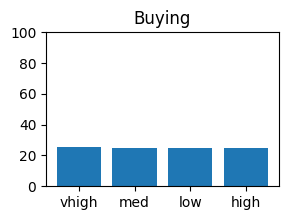

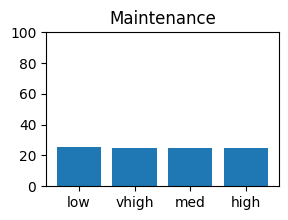

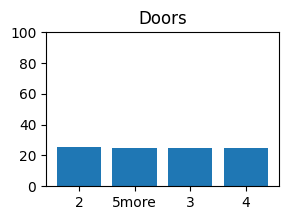

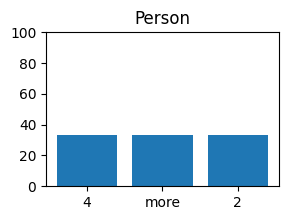

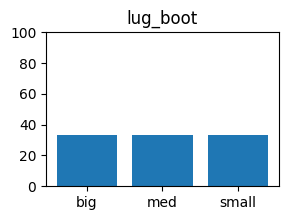

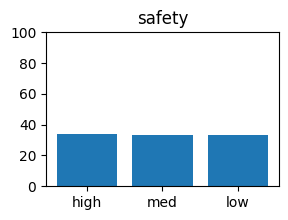

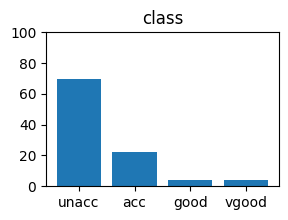

In [18]:
for col in df.columns:
    counts = df[col].value_counts(normalize=True)*100 # quiero usar valores normalizados para ver mejor la diferencia
    #print(f"\n{counts.round(2).to_string()}")

    plt.figure(figsize=(3, 2))
    plt.bar(counts.index, counts.values)
    plt.title(col)
    plt.ylim(0, 100)
    plt.show()

Estas visualizaciones nos indican que no existen valores atípicos dentro de los valores de entrada, pero si podemos apreciar que existen pocos casos donde estos datos obtienen una clase diferente a inaceptable (unacc).

#### Fase 5 - Análisis de correlación entre variables
Primero vamos a generar la matriz de correlación para poder visualizar como se influencian entre sí los datos.

Matriz de correlación:

             Buying  Maintenance  Doors  Person  lug_boot  safety  class
Buying         1.00         0.01  -0.01   -0.00     -0.00   -0.00  -0.29
Maintenance    0.01         1.00  -0.00   -0.01     -0.00   -0.01  -0.25
Doors         -0.01        -0.00   1.00   -0.00     -0.00   -0.00   0.07
Person        -0.00        -0.01  -0.00    1.00      0.00    0.01   0.34
lug_boot      -0.00        -0.00  -0.00    0.00      1.00   -0.00   0.16
safety        -0.00        -0.01  -0.00    0.01     -0.00    1.00   0.44
class         -0.29        -0.25   0.07    0.34      0.16    0.44   1.00


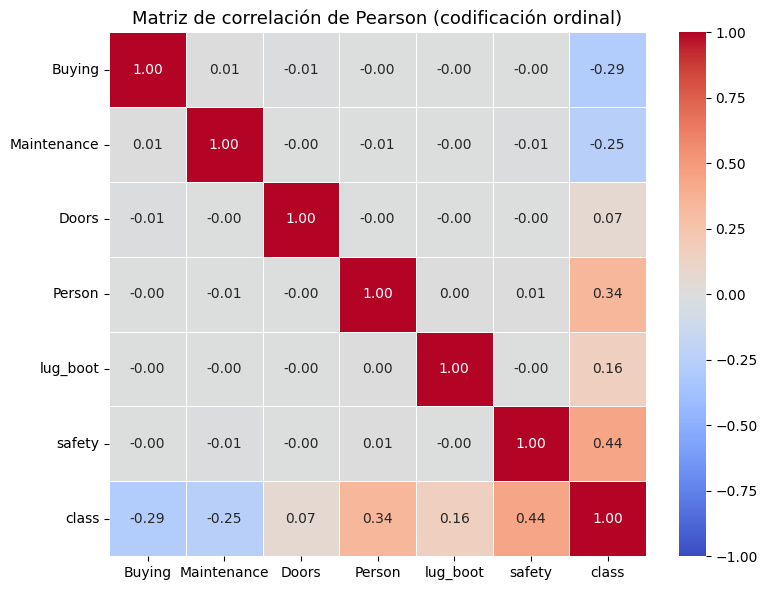

In [19]:
# Definimos el orden lógico de cada atributo
ordenes = [
    ["low", "med", "high", "vhigh"],  # Buying
    ["low", "med", "high", "vhigh"],  # Maintenance
    ["2", "3", "4", "5more"],         # Doors
    ["2", "4", "more"],               # Person
    ["small", "med", "big"],          # lug_boot
    ["low", "med", "high"],           # safety
    ["unacc", "acc", "good", "vgood"] # class
]

oe = OrdinalEncoder(categories = ordenes)
df_encoded = pd.DataFrame(
    oe.fit_transform(df),
    columns = df.columns
)

# Matriz de correlación
correlacion = df_encoded.corr()

print("Matriz de correlación:\n")
print(correlacion.round(2).to_string())

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1,
            linewidths=0.5)
plt.title("Matriz de correlación de Pearson (codificación ordinal)", fontsize=13)
plt.tight_layout()
plt.show()

Gracias a la matriz de correlación podemos observar como la clase del vehículo (su aceptación) empeora cuando el precio es altamente elevado (buying es vhigh) y/o requiere mucho manteniemiento (maintenance es vhigh). Lo contrario sucede cuanto el vehículo tiene mayor número de asientos (person es 5more) y/o es muy seguro (safety es high). Cabe destacar que el tamaño del maletero y el númro de puertas afecta positivamente, aunque en menor medidad que el número de asientos, a la clase final del vehículo.

## Preprocesamiento del dataset. Transformaciones previas necesarias para la modelación

In [ ]:
#Código que realice las transformaciones necesarias para poder realizar los procesos de modelación. Ej.One hot enconding

## División del dataset en datos de entrenamiento y datos de test 

In [ ]:
#Código que realice la división en entrenamiento y test, de acuerdo con la estretgia de evluación planeada. Describa cuál es.

## Ajuste de los modelos de clasificación propuestos

Justifique la selección de las dos propuestas de modelación seleccionadas:

In [ ]:
#Código de ajuste del modelo de clasificación 1

In [ ]:
#Código de ajuste del modelo de clasificación 2

## Evaluación de cada modelo

Al menos incluya:

+ Instancias clasificadas correctamente
+ Instancias clasificadas incorrectamente
+ TP Rate
+ FP Rate
+ Matriz de confusión


In [ ]:
#Código para mostrar la evaluación del modelo de clasificación 1

Construya un párrafo con los principales hallazgos.

In [ ]:
#Código  para mostrarla evaluación del modelo de clasificación 2

Construya un párrafo con los principales hallazgos.

## Comparación del desempeño de modelos

In [ ]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en tabla

In [ ]:
#Código para mostrar la comparación de métricas de desempeño de las dos propuestas en gráfica

Construya un párrafo con los principales hallazgos.

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

Realice en este espacio todo el análsis de resultados final incluyendo: ventajas y desventajas de cada modelo propuesto, Resultados comparados. Conclusiones objetivas y significantes con base a las diferentes métricas escogidas. Recomendaciones de mejora de las propuestas: 